## Sampling

Sampling serves as a fundamental technique for acquiring insights into a population by gathering data from a representative subset, rather than assessing every individual within the population. It presents a pragmatic approach when exhaustive data collection proves impractical. However, it is imperative that the sample mirrors the population's characteristics accurately.

### Probability Sampling

Probability sampling ensures that every member of the population possesses an equal chance of selection, thereby facilitating the creation of a sample that faithfully mirrors the population. Several commonly employed probability sampling techniques include:

1. **Simple random sampling**: Subjects are selected entirely at random, without bias or preference, ensuring each has an equal probability of inclusion.

2. **Stratified random sampling**: The population undergoes division into non-overlapping groups, from which subjects are randomly chosen. This method ensures representation across all relevant categories or strata.

3. **Systematic random sampling**: Subjects are chosen at regular intervals, offering simplicity in execution but potentially risking representativeness if the interval choice is inappropriate.

4. **Cluster sampling**: The population divides into non-overlapping clusters, from which a subset is randomly selected. This method offers convenience and cost-effectiveness.

Advantages of Probability Sampling
- Mitigation of Sample Bias
- Representation of Diverse Population Characteristics
- Generation of Accurate Sample Representations

### Non-Probability Sampling

Non-probability sampling deviates from the principle of equal probability of selection, thus increasing the likelihood of acquiring a non-representative sample. Commonly utilized non-probability sampling techniques include:

1. **Convenience sampling**: Conveniently accessible subjects form the sample, often leading to ease of implementation but potential representativeness issues.

2. **Judgmental or purposive sampling**: Selection is based on predefined criteria, aligning with the study's objectives, albeit potentially biasing the sample.

3. **Quota sampling**: Quotas ensure the sample reflects significant population characteristics, albeit without the assurance of equal probability of selection.

4. **Snowball sampling**: Initial subjects refer additional participants, commonly employed in populations with low visibility.

**Note**: Non-probability sampling typically yields less reliable and less generalizable results compared to probability sampling methodologies.


## Types of Errors in Sampling

When making inferences about a population based on a sample, it's possible to encounter various types of errors. These errors can be grouped into the following categories:

- **Sampling Error**: The difference between the sample estimate for the population and the actual population estimate
- **Coverage Error**: Occurs when the population is not adequately represented and some groups are excluded
- **Nonresponse Error**: Occurs when we fail to include nonresponsive subjects who meet the criteria of the study, but are excluded because they do not answer the survey questions.
- **Measurement Error**: Occurs when the correct parameters are not measured due to flaws in the measurement method or tool used.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(seed=42)

# Synthetic population: 10,000 individuals, income right-skewed
N = 10_000
group  = rng.choice(['low','high'], size=N, p=[0.7, 0.3])
income = np.where(
    group == 'low',
    rng.lognormal(mean=10.5, sigma=0.4, size=N),
    rng.lognormal(mean=11.5, sigma=0.5, size=N),
)
population = pd.DataFrame({'income': income, 'group': group})
pop_mean   = population['income'].mean()
print(f'Population size      : {N:,}')
print(f'True population mean : ${pop_mean:,.0f}')


Population size      : 10,000
True population mean : $61,533


### SRS vs Stratified Sampling

**Simple Random Sampling (SRS):** every individual has equal probability of selection — simple but
can over/under-represent subgroups by chance.  
**Stratified Sampling:** sample proportionally from each subgroup — reduces variance when
subgroups differ substantially in the outcome variable.

In [2]:
n = 100

# Simple random sample
srs = population.sample(n=n, random_state=42)

# Stratified sample (maintain 70/30 split)
strat = population.groupby('group', group_keys=False).apply(
    lambda g: g.sample(frac=n / N, random_state=42)
)

print(f'True mean     : ${pop_mean:,.0f}')
print(f'SRS mean      : ${srs["income"].mean():,.0f}  (error ${abs(srs["income"].mean()-pop_mean):,.0f})')
print(f'Stratified    : ${strat["income"].mean():,.0f}  (error ${abs(strat["income"].mean()-pop_mean):,.0f})')


True mean     : $61,533
SRS mean      : $52,841  (error $8,692)
Stratified    : $63,221  (error $1,688)


/sessions/adoring-sharp-goldberg/tmp/ipykernel_98/1635686848.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  strat = population.groupby('group', group_keys=False).apply(


### Sampling Error vs Sample Size

As sample size grows, the expected absolute sampling error shrinks as **σ/√n** (CLT).

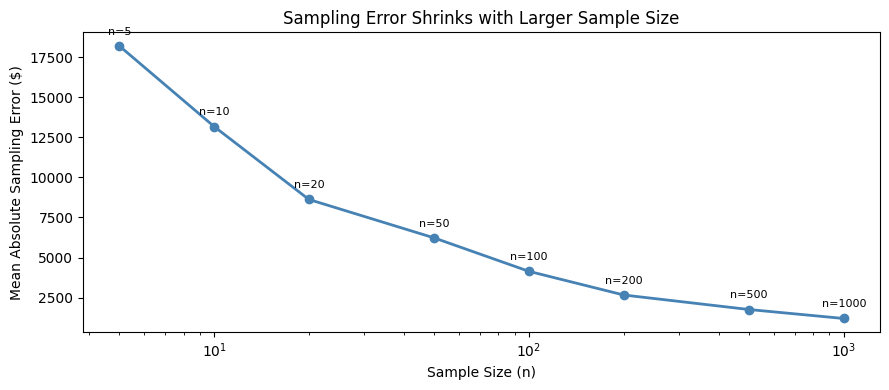

In [3]:
sample_sizes = [5, 10, 20, 50, 100, 200, 500, 1000]
n_reps = 500
mean_errors = []
for ns in sample_sizes:
    errors = [
        abs(population['income'].sample(n=ns, random_state=int(rng.integers(1e6))).mean() - pop_mean)
        for _ in range(n_reps)
    ]
    mean_errors.append(np.mean(errors))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(sample_sizes, mean_errors, 'o-', color='steelblue', lw=2)
ax.set_xlabel('Sample Size (n)')
ax.set_ylabel('Mean Absolute Sampling Error ($)')
ax.set_title('Sampling Error Shrinks with Larger Sample Size')
ax.set_xscale('log')
for ns, e in zip(sample_sizes, mean_errors):
    ax.annotate(f'n={ns}', xy=(ns, e), xytext=(0, 8),
                textcoords='offset points', ha='center', fontsize=8)
plt.tight_layout()
plt.show()


---
## ML/AI Connection

- **Train/val/test split** is sampling — the test set is a random sample used to estimate generalisation performance. Non-representative sampling leads to optimistic bias.
- **Stratified sampling** is used in `sklearn.model_selection.train_test_split(stratify=y)` to preserve class proportions across splits.
- **Imbalanced learning:** under/over-sampling (SMOTE, random undersampling) are deliberate sampling strategies to correct class imbalance.
- **Data leakage** is a form of coverage error — the test set is not a representative sample of future data.
